# 2. Machine Learning for Regression

In [1]:
import pandas as pd
import numpy as np

## 2.2 Data Preparation

In [2]:
df = pd.read_csv('../data/data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [3]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [4]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [5]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [6]:
df.dtypes.isin(['object', 'string'])

make                 False
model                False
year                 False
engine_fuel_type     False
engine_hp            False
engine_cylinders     False
transmission_type    False
driven_wheels        False
number_of_doors      False
market_category      False
vehicle_size         False
vehicle_style        False
highway_mpg          False
city_mpg             False
popularity           False
msrp                 False
dtype: bool

In [7]:
df.dtypes[df.dtypes.isin(['object', 'string'])]

Series([], dtype: object)

In [8]:
strings = list(df.select_dtypes(include=['object', 'string']).columns)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [9]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [10]:
df[strings]

,make,model,engine_fuel_type,transmission_type,driven_wheels,market_category,vehicle_size,vehicle_style
0,bmw,1_series_m,premium_unleaded_(required),manual,rear_wheel_drive,"factory_tuner,luxury,high-performance",compact,coupe
1,bmw,1_series,premium_unleaded_(required),manual,rear_wheel_drive,"luxury,performance",compact,convertible
2,bmw,1_series,premium_unleaded_(required),manual,rear_wheel_drive,"luxury,high-performance",compact,coupe
3,bmw,1_series,premium_unleaded_(required),manual,rear_wheel_drive,"luxury,performance",compact,coupe
4,bmw,1_series,premium_unleaded_(required),manual,rear_wheel_drive,luxury,compact,convertible
...,...,...,...,...,...,...,...,...
11909,acura,zdx,premium_unleaded_(required),automatic,all_wheel_drive,"crossover,hatchback,luxury",midsize,4dr_hatchback
11910,acura,zdx,premium_unleaded_(required),automatic,all_wheel_drive,"crossover,hatchback,luxury",midsize,4dr_hatchback
11911,acura,zdx,premium_unleaded_(required),automatic,all_wheel_drive,"crossover,hatchback,luxury",midsize,4dr_hatchback
11912,acura,zdx,premium_unleaded_(recommended),automatic,all_wheel_drive,"crossover,hatchback,luxury",midsize,4dr_hatchback


In [11]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

## 2.3 Exploratory data analysis

In [12]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


In [13]:
for col in df.columns:
    print(col)
    print(df[col].head())
    print()

make
0    bmw
1    bmw
2    bmw
3    bmw
4    bmw
Name: make, dtype: str

model
0    1_series_m
1      1_series
2      1_series
3      1_series
4      1_series
Name: model, dtype: str

year
0    2011
1    2011
2    2011
3    2011
4    2011
Name: year, dtype: int64

engine_fuel_type
0    premium_unleaded_(required)
1    premium_unleaded_(required)
2    premium_unleaded_(required)
3    premium_unleaded_(required)
4    premium_unleaded_(required)
Name: engine_fuel_type, dtype: str

engine_hp
0    335.0
1    300.0
2    300.0
3    230.0
4    230.0
Name: engine_hp, dtype: float64

engine_cylinders
0    6.0
1    6.0
2    6.0
3    6.0
4    6.0
Name: engine_cylinders, dtype: float64

transmission_type
0    manual
1    manual
2    manual
3    manual
4    manual
Name: transmission_type, dtype: str

driven_wheels
0    rear_wheel_drive
1    rear_wheel_drive
2    rear_wheel_drive
3    rear_wheel_drive
4    rear_wheel_drive
Name: driven_wheels, dtype: str

number_of_doors
0    2.0
1    2.0
2    2.0
3

In [14]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

### Distribution of price

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

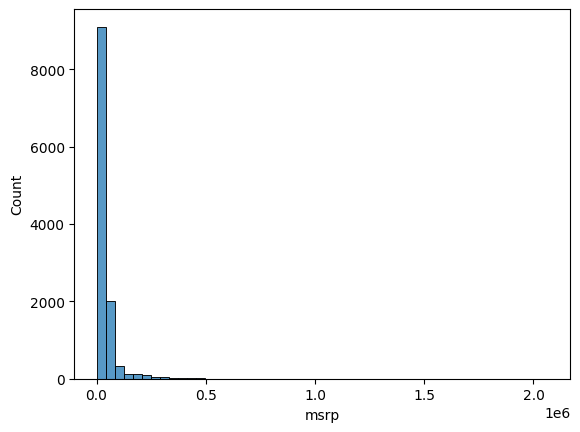

In [16]:
sns.histplot(df.msrp, bins=50);

We can see long tail distribution in the graph above.
1e6 - one million, 1_000_000.
Possible prices might be around 2 million.

Zoom in a bit to see prices up to 100_000

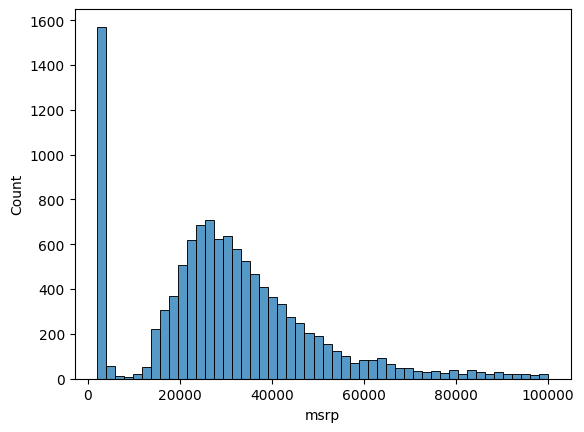

In [17]:
sns.histplot(df.msrp[df.msrp < 100_000], bins=50);

We can see a bunch of cars at minimal price, around 1000, the average in this zoomed in is around 25_000.
This kind of distribution is not very good for ML. The tail from the zoomed-out graph will easily confuse ML models.
We want to get rid of that tail.  
To remove it we apply a logarithms to obtain a logarithnmic distribution to get more compact values.  
What's the reason for that? Simple mathematical behavior of logarithms - log of large values are not increasing rapidly.

In [18]:
np.log([1, 10, 1000, 100_000])

array([ 0.        ,  2.30258509,  6.90775528, 11.51292546])

The problem with common logs is that if we calculate logs for zero values, we will get a warning because the log(0) is undefined.
The solution is add to 1 to all values and then apply a log on them.

In [19]:
np.log([0 + 1, 1 + 1, 10 + 1, 1000 + 1, 100_000 + 1])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

But we don't want to do this manually each time.   
There is a method in numpy that applies such a log on our data.

In [20]:
np.log1p([0, 1, 10, 1000, 100_000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [21]:
price_logs = np.log1p(df.msrp)

In [22]:
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

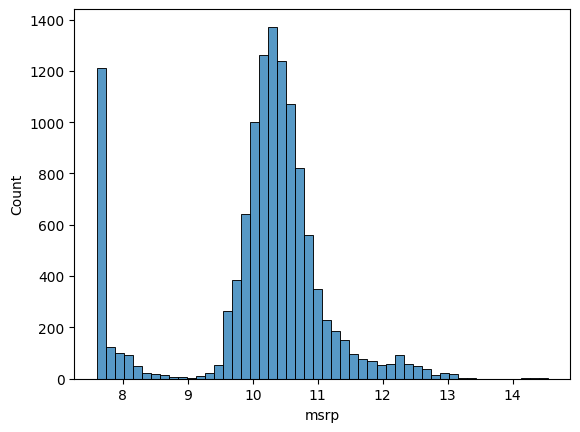

In [23]:
sns.histplot(price_logs, bins=50);

The tail is gone and all large prices have collapsed to the area around 14.
All the prices for usual consumers are pivoting around 10 and 11.
This shape is now called a **normal distribution**.  
Models work best with normal distributions of the target variable.

## Missing values

In [24]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

# 2.4 Setting up the validation framework

In [25]:
len(df)

11914

In [26]:
len(df) * .2

2382.8

In [27]:
n = len(df)
n_val = int(n * .2)
n_test = int(n * .2)
n_train = int(n * .6)

In [28]:
n, n_val + n_test + n_train

(11914, 11912)

We can see that we left out 2 records, so we need different approach.

In [29]:
n_train = n - n_val - n_test
n_train

7150

In [30]:
n, n_val + n_test + n_train

(11914, 11914)

In [31]:
n_val, n_test, n_train

(2382, 2382, 7150)

In [32]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

In [33]:
df.iloc[11910:]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920
11913,lincoln,zephyr,2006,regular_unleaded,221.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,26,17,61,28995


In [34]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,mazda,navajo,1994,regular_unleaded,160.0,6.0,manual,four_wheel_drive,2.0,NaN,compact,2dr_suv,18,14,586,2000
7146,mazda,navajo,1994,regular_unleaded,160.0,6.0,manual,four_wheel_drive,2.0,NaN,compact,2dr_suv,18,14,586,2000
7147,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,65055
7148,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,67220


In [35]:
df_val

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
7150,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,63645
7151,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,22,16,61,63195
7152,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,76650
7153,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,69135
7154,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,65560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,22,17,1385,37380
9528,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,extended_cab_pickup,23,16,1385,40100
9529,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,crew_cab_pickup,23,16,1385,42560
9530,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,crew_cab_pickup,23,16,1385,42860


In [36]:
df_test

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
9532,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,crew_cab_pickup,23,16,1385,47575
9533,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,24,18,1385,31940
9534,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,24,18,1385,38335
9535,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,24,18,1385,35870
9536,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,rear_wheel_drive,2.0,flex_fuel,large,regular_cab_pickup,24,18,1385,28155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


Another problem is that all the data is sequential - we have to shuffle the data.

In [37]:
idx = np.arange(n)

In [38]:
idx

array([    0,     1,     2, ..., 11911, 11912, 11913], shape=(11914,))

In [39]:
np.random.shuffle(idx)

In [40]:
idx

array([ 6811,  8841,  2965, ..., 11247, 11218,  4215], shape=(11914,))

In [41]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [42]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
6811,mazda,millenia,2002,regular_unleaded,170.0,6.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,24,17,586,28075
8841,mercedes-benz,s-class,2017,premium_unleaded_(required),449.0,8.0,automatic,rear_wheel_drive,4.0,"luxury,high-performance",large,sedan,26,18,617,96600
2965,chevrolet,corvette_stingray,2014,premium_unleaded_(recommended),455.0,8.0,manual,rear_wheel_drive,2.0,high-performance,compact,coupe,29,17,1385,57000
3630,dodge,durango,2017,regular_unleaded,295.0,6.0,automatic,all_wheel_drive,4.0,crossover,large,4dr_suv,25,18,1851,40095
8984,hyundai,santa_fe_sport,2017,regular_unleaded,265.0,4.0,automatic,front_wheel_drive,4.0,crossover,midsize,4dr_suv,27,20,1439,36500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2077,mercedes-benz,c-class,2016,premium_unleaded_(required),241.0,4.0,automatic,rear_wheel_drive,4.0,luxury,midsize,sedan,34,25,617,38950
1230,honda,accord,2015,regular_unleaded,185.0,4.0,automatic,front_wheel_drive,2.0,NaN,midsize,coupe,35,26,2202,24625
1260,honda,accord,2017,regular_unleaded,185.0,4.0,manual,front_wheel_drive,2.0,NaN,midsize,coupe,32,23,2202,24025
5663,volkswagen,gti,2013,premium_unleaded_(recommended),200.0,4.0,automated_manual,front_wheel_drive,4.0,"hatchback,performance",compact,4dr_hatchback,33,24,873,32095


The problem with this approach that each time we will get different random portions.  
We need to keep it reproducible with pseudo-random shuffling. 

In [43]:
np.random.seed(2)
idx = np.arange(n)
np.random.shuffle(idx)

Split the data again.

In [44]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [45]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
434,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,54900
1902,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,29215
9334,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549,34675
5284,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86,303300


In [46]:
df_test

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
11195,gmc,vandura,1994,regular_unleaded,165.0,6.0,automatic,rear_wheel_drive,3.0,NaN,compact,cargo_van,20,15,549,2000
673,mercedes-benz,600-class,1993,regular_unleaded,389.0,12.0,automatic,rear_wheel_drive,2.0,luxury,large,coupe,15,11,617,3211
11270,toyota,venza,2013,regular_unleaded,268.0,6.0,automatic,all_wheel_drive,4.0,"crossover,performance",midsize,wagon,25,18,2031,31120
752,volvo,740,1992,regular_unleaded,114.0,4.0,automatic,rear_wheel_drive,4.0,luxury,midsize,sedan,26,18,870,2000
3137,ford,crown_victoria,2010,flex-fuel_(unleaded/e85),224.0,8.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,sedan,24,16,5657,29905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2514,chevrolet,chevy_van,1998,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,3.0,NaN,midsize,cargo_van,18,13,1385,2052
11798,subaru,xv_crosstrek,2014,regular_unleaded,160.0,4.0,automatic,all_wheel_drive,4.0,"crossover,hybrid",compact,4dr_suv,33,29,640,25995
6637,dodge,magnum,2006,regular_unleaded,250.0,6.0,automatic,all_wheel_drive,4.0,NaN,large,wagon,22,15,1851,29100
2575,honda,civic,2016,regular_unleaded,174.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,42,31,2202,22200


In [47]:
df_val

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2779,chevrolet,colorado,2015,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,1385,26885
3708,mercedes-benz,e-class,2017,premium_unleaded_(required),241.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,29,22,617,54650
4794,ford,focus,2017,flex-fuel_(unleaded/e85),160.0,4.0,manual,front_wheel_drive,4.0,flex_fuel,compact,sedan,36,26,5657,16775
10498,acura,tlx,2016,premium_unleaded_(recommended),290.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,34,21,204,42600
1880,volkswagen,beetle_convertible,2016,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,2.0,NaN,compact,convertible,34,25,873,25995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11123,volvo,v60,2015,regular_unleaded,240.0,4.0,automatic,front_wheel_drive,4.0,luxury,midsize,wagon,37,25,870,35750
5549,maserati,granturismo_convertible,2015,premium_unleaded_(required),444.0,8.0,automatic,rear_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,20,13,238,145740
4146,cadillac,escalade_hybrid,2013,regular_unleaded,332.0,8.0,automatic,rear_wheel_drive,4.0,"luxury,hybrid",large,4dr_suv,23,20,1624,74425
6337,mitsubishi,lancer,2016,regular_unleaded,148.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,34,24,436,17595


In [48]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

We are not interested in the original indices, so we will reset all of them.

In [49]:
df_train = df_train.reset_index(drop=True)

In [50]:
df_val = df_val.reset_index(drop=True)

In [51]:
df_test = df_test.reset_index(drop=True)

Next, we need to do some transformation of the target variable.

In [52]:
df_train.msrp

0        14410
1        19685
2        19795
3         2000
4        56260
         ...  
7145     54900
7146     29215
7147     34675
7148    303300
7149     37820
Name: msrp, Length: 7150, dtype: int64

In [53]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

Remove the target variable from the training, validation and test subsets

In [54]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [55]:
len(y_train)

7150

In [56]:
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

# Linear regression

In [57]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86


In [58]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [59]:
xi = [311, 20, 454]

We will select engine_hp, city_mpg and popularity features for analysis on this one particular example.  
$x_{i} = [311, 20, 454]$  
$i = 10$  
$g(x_{i}) ≈ y_{i}$

In [60]:
def g(xi):
    # do something
    return 10_000

In [61]:
g(xi)

10000

Formula for linear regression:    
$g(x_{i}) = w_{0} + w_{1}*x_{i1} + w_{2}*x_{i2} + w_{3}*x_{i3}$

Final formula:  
$g(x_{i}) = w_{0} + \sum_{j=1}^{3}w_{j}x_{ij}$

where $w_{0}$ is a bias term.  
In our case, since index starts from 0 and goes to n-1, our formula is written like this:  
$g(x_{i}) = w_{0} + \sum_{j=0}^{n-1}w_{j}x_{ij}$

In [62]:
w0 = 0
w = [1, 1, 1]

In [63]:
def linear_regression(xi):
    n = len(xi)

    pred = w0
    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

In [64]:
linear_regression(xi)

785

Let's use some concrete values

In [65]:
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [66]:
linear_regression(xi)

11.988

Bias term $w_0$ is a prediction about a specific car if we don't know anything about it.  
But we actually know something about that car - we know the engine_hp. For each unit of engine_hp the price increases by 0.01.  
The more engine_hp the car has, the more expensive it becomes.  
For the city_mpg the more the car consumes in the city, the more expensive it becomes. For each extra mpg the price increases by 0.04.  
Logic behind the statement: the more the car consumes it must be one of the more expensive ones.  
The last feature is popularity (social media mentions) which has a low weight and is not affecting the price so much.  
For every extra mention the price increases by factor 0.002.  

The value yielded from the linear_regression in this case (11.988) does not represent the final price of the car, this is the log(y + 1) price.   
We need to undo the logarithm to obtain the final value.

In [67]:
np.exp(linear_regression(xi)) - 1

np.float64(160812.40553386137)

In [68]:
np.expm1(linear_regression(xi))

np.float64(160812.40553386137)

So, for this particular car the price prediction is around $160812.41.

# 2.6 Linear regression vector form

$g(x_{i}) = w_{0} + \sum_{j=1}^{3}w_{j}x_{ij}$  
$g(\mathbf{x}_i)=w_0 * x_{i0}+\mathbf{x}_i^T\mathbf{w}$  

where the imaginary feature $x_{i0}$ is always one.

$\mathbf{w} = [w_{0}, w_{1}, w_{2}, ..., w_{n}]$ is a n + 1 dimensional vector.  
$\mathbf{x_{i}} = [1, x_{i1}, x_{i2}, ..., x_{in}]$   

Then we do the dot product between them.

Vector by vector product

In [69]:
def dot(xi, w):
    n = len(xi)

    res = 0

    for j in range(n):
        res = res + xi[j] * w[j]

    return res

In [70]:
def linear_regression(xi):
    return w0 + dot(xi, w)

In [71]:
w_new = [w0] + w

In [72]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [73]:
[1] + [1, 2, 3]

[1, 1, 2, 3]

In [74]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [75]:
linear_regression(xi)

11.988

Now, we will thing about all the examples, not just concrete one.
We have a marix $\mathbf{X}$ of size m x (n+1) which means m rows and (n+1) columns.
We also have a vector $\mathbf{w}$.  
For each of these rows, we multiply the row with the vector.
The results or the predictions $\mathbf{y_p}$ are on the right-hand side of the equal sign.

$
\begin{bmatrix}
1 & x_{11} & \cdots & x_{1n}\\
1 & x_{21} & \cdots & x_{2n}\\
1 & \vdots & \ddots & \vdots\\
1 & x_{m1} & \cdots & x_{mn}
\end{bmatrix}
\begin{bmatrix}
w_0\\
w_1\\
\vdots\\
w_n
\end{bmatrix}
=
\begin{bmatrix}
x_1^T w\\
x_2^T w\\
\vdots\\
x_m^T w
\end{bmatrix}
$

In [76]:
xi = [311, 20, 454]
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

In [77]:
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 311, 20,  454]

X = [x1, x2, x10]
X

[[1, 148, 24, 1385], [1, 132, 25, 2031], [1, 311, 20, 454]]

In [78]:
X = np.array(X)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  311,   20,  454]])

In [79]:
X.dot(w_new)

array([12.38 , 13.552, 11.988])

In [80]:
X @ w_new

array([12.38 , 13.552, 11.988])

For each car now we have a prediction of its price.

In [81]:
def linear_regression(X):
    return X.dot(w_new)

In [82]:
linear_regression(X)

array([12.38 , 13.552, 11.988])

# 2.7 Training a linear regression model

We tend to be as close as possible to the following situation:  
$\mathbf{Xw} = \mathbf{y}$  
but in reality, we never get there, so the formula looks more like the following:  
$\mathbf{Xw} ≈ \mathbf{y}$  
We want to find the weights, so we need to multiply the $\mathbf{Xw}$ by $\mathbf{X^{-1}}$ (inverted matrix), 
and the other side to get the following expression:  
$\mathbf{X^{-1}} \mathbf{Xw} = \mathbf{X^{-1}} \mathbf{y}$  
so the expression becomes:  
$\mathbf{I} \mathbf{w} = \mathbf{X^{-1}} \mathbf{y}$  
if identity matrix exists, or more precisely: 
$\mathbf{w} = \mathbf{X^{-1}} \mathbf{y}$.

But the problem is that $\mathbf{X}$ is not rectangular matrix, and the inverse does not exist. 
That means that for our system of equations solution does not exist.  
So the goal is to find an approximate solution like this:  

$\mathbf{X^{T}} \mathbf{Xw} = \mathbf{X^{T}} \mathbf{y}$  

The matrix $\mathbf{X^{T}} \mathbf{X}$ is called **Gram matrix** and for it the inverse exists because it's squared  
with dimension (n+1) * (n+1). It doesn't always, and we will talk about it later.  

So, to calculate the weights, we have to multiply the gram matrix by its inverse to get the following expression:  
$(\mathbf{X^{T}X})^{-1} \mathbf{X^{T}Xw} = (\mathbf{X^{T}X})^{-1}\mathbf{X^{T}} \mathbf{y}$  
and again, we get the following:  
$\mathbf{I} \mathbf{w} = (\mathbf{X^{T}X})^{-1}\mathbf{X^{T}} \mathbf{y}$ or:  
$\mathbf{w} = (\mathbf{X^{T}X})^{-1}\mathbf{X^{T}} \mathbf{y}$  

$\mathbf{w}$ is not the solution of the system (the solution does not exist) but represents the closest possible solution.  
This can be proved mathematically (a very useful book for learning more of the mathematics regarding that - Elements of Statistical Learning).

In [83]:
def train_linear_regression(X, y):
    pass

In [84]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11,   86],
    [158, 24,  185],
    [172, 25,  201],
    [413, 11,   86],
    [ 38, 54,  185],
    [142, 25,  431],
    [453, 31,   86],
]

X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

Include the bias term (the baseline)

In [85]:
ones = np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [86]:
list(np.column_stack([ones, X]))

[array([1.000e+00, 1.480e+02, 2.400e+01, 1.385e+03]),
 array([1.000e+00, 1.320e+02, 2.500e+01, 2.031e+03]),
 array([  1., 453.,  11.,  86.]),
 array([  1., 158.,  24., 185.]),
 array([  1., 172.,  25., 201.]),
 array([  1., 413.,  11.,  86.]),
 array([  1.,  38.,  54., 185.]),
 array([  1., 142.,  25., 431.]),
 array([  1., 453.,  31.,  86.])]

In [87]:
X = np.column_stack([ones, X])

In [88]:
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]

In [89]:
# Gram matrix
XTX = X.T.dot(X)
XTX

array([[9.000000e+00, 2.109000e+03, 2.300000e+02, 4.676000e+03],
       [2.109000e+03, 6.964710e+05, 4.411500e+04, 7.185400e+05],
       [2.300000e+02, 4.411500e+04, 7.146000e+03, 1.188030e+05],
       [4.676000e+03, 7.185400e+05, 1.188030e+05, 6.359986e+06]])

In [90]:
XTX_inv = np.linalg.inv(XTX)
XTX_inv

array([[ 3.30686958e+00, -5.39612291e-03, -6.21325581e-02,
        -6.61016816e-04],
       [-5.39612291e-03,  1.11633857e-05,  8.66973393e-05,
         1.08664195e-06],
       [-6.21325581e-02,  8.66973393e-05,  1.46189255e-03,
         8.57849603e-06],
       [-6.61016816e-04,  1.08664195e-06,  8.57849603e-06,
         3.60215866e-07]])

In [91]:
# check
XTX.dot(XTX_inv).round(1)

array([[ 1., -0.,  0.,  0.],
       [-0.,  1.,  0., -0.],
       [-0.,  0.,  1.,  0.],
       [-0., -0.,  0.,  1.]])

We have an indentity matrix. The values are not exactly 0 above and below the diagonal, but close enough.

In [92]:
w_full = XTX_inv.dot(X.T).dot(y)
w_full

array([ 2.58447541e+04, -1.60890647e+01, -1.99472549e+02, -1.22802883e+00])

In [93]:
w0 = w_full[0]
w = w_full[1:]

In [94]:
w0, w

(np.float64(25844.754055766833),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

Negative values mean that price goes down if the feature value goes up. For example, greater car age, lower the price.

In [95]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

This time we don't need to put ones as the first column in $\mathbf{X}$, the algorithm does this for us.

In [96]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11,   86],
    [158, 24,  185],
    [172, 25,  201],
    [413, 11,   86],
    [ 38, 54,  185],
    [142, 25,  431],
    [453, 31,   86],
]

X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [97]:
train_linear_regression(X, y)

(np.float64(25844.754055766833),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

# 2.8 Car price baseline model

In [98]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86


The next goal is to extract numerical columns from the train set.

In [99]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [100]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [101]:
base = ['engine_hp','engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']
df_train[base]

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,148.0,4.0,33,24,1385
1,132.0,4.0,32,25,2031
2,148.0,4.0,37,28,640
3,90.0,4.0,18,16,873
4,385.0,8.0,21,15,5657
...,...,...,...,...,...
7145,300.0,6.0,31,20,3916
7146,210.0,4.0,30,24,873
7147,285.0,6.0,22,17,549
7148,563.0,12.0,21,13,86


Extract the values from the basic numeric columns.

In [102]:
X_train = df_train[base].values
X_train

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]], shape=(7150, 5))

In [103]:
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

Train the model

In [104]:
train_linear_regression(X_train, y_train)

(np.float64(nan), array([nan, nan, nan, nan, nan]))

We have some missing values we need to fix.

In [105]:
df_train[base].isnull().sum()

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

The easiest approach is to fill them with zeroes.

In [106]:
df_train[base].fillna(0).isnull().sum()

engine_hp           0
engine_cylinders    0
highway_mpg         0
city_mpg            0
popularity          0
dtype: int64

That way we kind of make the model ignore those rows.  
$g(x_{i}) = w_{0} + x_{i1}*w_{1} + x_{i2}*w_{2}$  

Say $x_{i1}$ is missing, the term becomes  
$g(x_{i}) = w_{0} + x_{i2}*w_{2}$  

Zeros are not always the best approach to deal with missing values.  
For example, it does not make much sense for engine horsepower to be 0 hp.  
It's like there is an engine with 0 cylinders.  
Since we don't want to complicate the procedure, we will take this approach for now.

In [107]:
X_train = df_train[base].fillna(0).values
X_train

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]], shape=(7150, 5))

In [108]:
w0, w = train_linear_regression(X_train, y_train)
w0, w

(np.float64(7.927257388069851),
 array([ 9.70589522e-03, -1.59103494e-01,  1.43792133e-02,  1.49441072e-02,
        -9.06908672e-06]))

The next step is to take those weights and make predictions.

In [109]:
y_pred = w0 + X_train.dot(w)
y_pred

array([ 9.54792783,  9.38733977,  9.67197758, ..., 10.30423015,
       11.9778914 ,  9.99863111], shape=(7150,))

Next, we will plot the prodictions to see if they look similar to the original target variable data that we want to predict.

<Axes: ylabel='Count'>

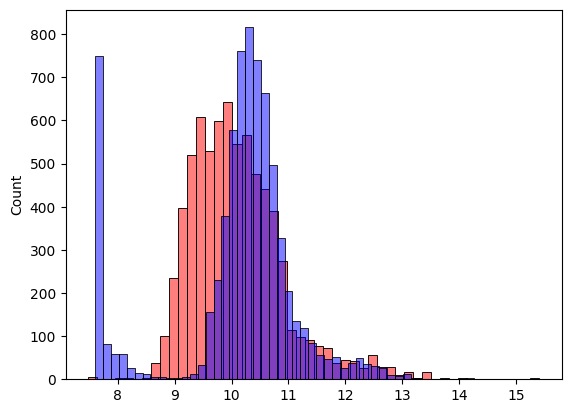

In [110]:
sns.histplot(y_pred, color='red', alpha=.5, bins=50)
sns.histplot(y_train, color='blue', alpha=.5, bins=50)

Our model predicts smaller value and we can see the peak of the distribution for the y_pred slightly moved to the left.
Just by looking the histogram we can see that our model is not very good but on the other hand we need to measure it.
When we start to improve our model, we want to make sure that we indeed improved it, not just by looking at the histogram.

# 2.9 RMSE

RMSE formula:  
$RMSE = \sqrt{\frac{1}{m}\sum_{i=1}^{m}(g(x_{i}) - y_{i})^2}$  
where $g(x_{i})$ is a prediction for $x_{i}$ and $y_{i}$ is an actual value.

The expression $g(x_{i}) - y_{i}$ is the difference between the predicted price and the actual price.

In [111]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [112]:
rmse(y_train, y_pred)

np.float64(0.7554192603920132)

# 2.10 Validating the model

The next step is to calculate RMSE on validation subset.

In [113]:
base = ['engine_hp','engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

X_train = df_train[base].fillna(0).values

w0, w = train_linear_regression(X_train, y_train)

y_pred = w0 + X_train.dot(w)

In [114]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [115]:
# training
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

# validation
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.7616530991301604)

Now we have a way of valuating the quality of our model and can start on improving the model.

# 2.11 Simple feature engineering

In [116]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86


*year* is one of the most important variables in predcting car prices.  
Usually, if a car is old the price is lower, and vice versa.
Instead of using this variable directly, we can compute the age for each car and use that as new feature.  
First, we check when the data was collected.

In [117]:
df_train.year.max()

np.int64(2017)

Imagine that now is 2017 and we want to use this year to calculate the car age.

In [118]:
2017 - df_train.year

0        9
1        5
2        1
3       26
4        0
        ..
7145     2
7146     2
7147     2
7148     3
7149     0
Name: year, Length: 7150, dtype: int64

As we can see, some cars are new (0 years old), an some of them are quite old (27).  
We want to use this new information as a feature.

In [119]:
"""
def prepare_X(df):
    df['age'] = 2017 - df.year
    features = base + ['age'] 
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X
"""

"\ndef prepare_X(df):\n    df['age'] = 2017 - df.year\n    features = base + ['age'] \n\n    df_num = df[features]\n    df_num = df_num.fillna(0)\n    X = df_num.values\n    return X\n"

In [120]:
"""
X_train = prepare_X(df_train)
df_train.dtypes
"""

'\nX_train = prepare_X(df_train)\ndf_train.dtypes\n'

We can see that *age* column was added to the training dataset.
But we cannot have this function modify the original dataset and we need to make some modification so it works with the copy.

In [121]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df.year
    features = base + ['age'] 
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [122]:
X_train = prepare_X(df_train)
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [123]:
X_train

array([[1.480e+02, 4.000e+00, 3.300e+01, 2.400e+01, 1.385e+03, 9.000e+00],
       [1.320e+02, 4.000e+00, 3.200e+01, 2.500e+01, 2.031e+03, 5.000e+00],
       [1.480e+02, 4.000e+00, 3.700e+01, 2.800e+01, 6.400e+02, 1.000e+00],
       ...,
       [2.850e+02, 6.000e+00, 2.200e+01, 1.700e+01, 5.490e+02, 2.000e+00],
       [5.630e+02, 1.200e+01, 2.100e+01, 1.300e+01, 8.600e+01, 3.000e+00],
       [2.000e+02, 4.000e+00, 3.100e+01, 2.200e+01, 8.730e+02, 0.000e+00]],
      shape=(7150, 6))

We did not keep the *age* feature. We only needed it to compute the X.
It can be seen that X_train does not contain the *age* column.

In [124]:
w0, w = train_linear_regression(X_train, y_train)

# validation
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.517205546105833)

Indeed, we can see that our model improved greatly on RMSE.  
We can also see that improvement graphically.

<Axes: ylabel='Count'>

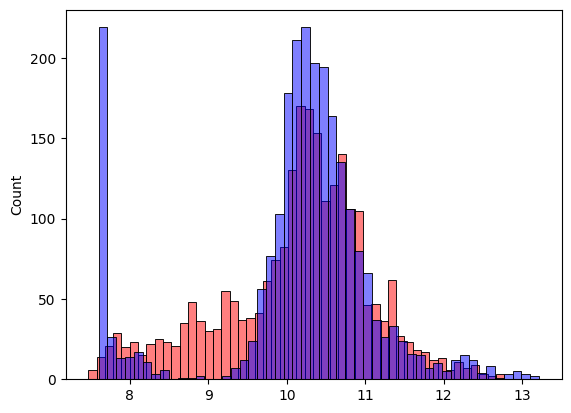

In [125]:
sns.histplot(y_pred, color='red', alpha=.5, bins=50)
sns.histplot(y_val, color='blue', alpha=.5, bins=50)

Since we made a prediction on the validation set, we are comparing the actual prices from that set with the predicted prices from the same set.
At least the peaks are matching, but we see the left side of the prediction curve is having some troubles.  
Also, the prediction completely missed the far left peak, and it got some differences in values at the peeks.

# 2.12 Categorical variables

In [126]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

All the categorical variables are displayed as strings but there is one variable that looks like numerical but its behavior is categorical, namely number_of_doors.  
The explanation is simple - there are cars with two doors, three doors and four doors. Those are categories of cars and those cars are quite different.  
We want to use such variables as categorical values because they bear importance for our model.  
For example, cars with two doors might be more expensive than cars with four doors (e.g. they could be luxury sport cars).  
Tipically way of encoding such categorical variables is to represent them as a bunch of binary variables (e.g. num_doors_2, num_doors_3, and num_doors_4).  
So, we will represent one categorical variable with numerical values as three separate binary variables.  

In [127]:
df_train.number_of_doors == 2

0        True
1       False
2       False
3       False
4       False
        ...  
7145     True
7146     True
7147    False
7148    False
7149    False
Name: number_of_doors, Length: 7150, dtype: bool

In [128]:
df_train.number_of_doors == 3

0       False
1       False
2       False
3        True
4       False
        ...  
7145    False
7146    False
7147    False
7148    False
7149    False
Name: number_of_doors, Length: 7150, dtype: bool

In [129]:
df_train.number_of_doors == 4

0       False
1        True
2        True
3       False
4        True
        ...  
7145    False
7146    False
7147     True
7148     True
7149     True
Name: number_of_doors, Length: 7150, dtype: bool

In [130]:
(df_train.number_of_doors == 2).astype('int')

0       1
1       0
2       0
3       0
4       0
       ..
7145    1
7146    1
7147    0
7148    0
7149    0
Name: number_of_doors, Length: 7150, dtype: int64

In [131]:
(df_train.number_of_doors == 3).astype('int')

0       0
1       0
2       0
3       1
4       0
       ..
7145    0
7146    0
7147    0
7148    0
7149    0
Name: number_of_doors, Length: 7150, dtype: int64

In [132]:
(df_train.number_of_doors == 4).astype('int')

0       0
1       1
2       1
3       0
4       1
       ..
7145    0
7146    0
7147    1
7148    1
7149    1
Name: number_of_doors, Length: 7150, dtype: int64

In [133]:
"""
for v in [2, 3, 4]:
    df_train['num_doors_%s' % v] = (df_train.number_of_doors == v).astype('int')
"""

"\nfor v in [2, 3, 4]:\n    df_train['num_doors_%s' % v] = (df_train.number_of_doors == v).astype('int')\n"

But we will not do this here but in our *prepare_X* method instead.  
We wil also add these new column names to our features array.

In [134]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()
    
    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    
    return X

In [135]:
prepare_X(df_train)

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [285.,   6.,  22., ...,   0.,   0.,   1.],
       [563.,  12.,  21., ...,   0.,   0.,   1.],
       [200.,   4.,  31., ...,   0.,   0.,   1.]], shape=(7150, 9))

In [136]:
# prepare data
X_train = prepare_X(df_train)

# train the model
w0, w = train_linear_regression(X_train, y_train)

# validate the model
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5157995641501902)

We can see the slight improvement on RMSE.  
The conclusion is that *number_of_doors* feature is not very useful for our model.

We will try with *make* variable as it should suposedly affect the model.

In [137]:
df.make.nunique()

48

Inspect the most popular manufacturers.

In [138]:
df.make.value_counts().head()

make
chevrolet     1123
ford           881
volkswagen     809
toyota         746
dodge          626
Name: count, dtype: int64

In [139]:
df.make.value_counts().head().index

Index(['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'], dtype='str', name='make')

In [140]:
makes = list(df.make.value_counts().head().index)

We can include the most popular make values in our data preparation function.

In [141]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()
    
    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    for v in makes:
        df['make_%s' % v] = (df.make == v).astype('int')
        features.append('make_%s' % v)
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    
    return X

In [142]:
# prepare data
X_train = prepare_X(df_train)

# train the model
w0, w = train_linear_regression(X_train, y_train)

# validate the model
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5076038849554877)

We can see some improvement on RMSE but not relevant as with age.

We can do the same for other categorical variables.

In [143]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

We will not list *model* variable in the categories because there are too many models.

In [144]:
categorical_variables = [
    'make', 'engine_fuel_type', 'transmission_type', 
    'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style'
]

Now, we can basically do the same thing like we did with *make* variable but all at once.

In [145]:
categories = {}

for c in categorical_variables:
    categories[c] = list(df[c].value_counts().head().index)

categories

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

Now, we'll take the *prepare_X* function and throw in all the categories.

def prepare_X(df):
    df = df.copy()
    features = base.copy()
    
    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    for c, values in categories.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
            features.append('%s_%s' % (c, v))
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    
    return X

In [147]:
# prepare data
X_train = prepare_X(df_train)

# train the model
w0, w = train_linear_regression(X_train, y_train)

# validate the model
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(28.716155086919994)

In this last attempt to lower the RMSE we failed.

In [149]:
int(w0)

-4508250884733021

In [155]:
w

array([-1.82554002e-01, -4.15951109e+00, -1.56097372e+00, -3.35223499e+00,
       -1.41326191e-03, -2.26531333e+00, -4.67275179e+02, -4.87646009e+02,
       -4.71715334e+02,  1.73294249e-01,  5.90832071e-01, -1.02420020e+01,
        8.09236207e+00, -1.37583514e+00, -9.02670032e+01, -8.05254196e+01,
       -8.98003910e+01, -9.52202754e+01, -7.68501684e+01,  2.97877666e+15,
        2.97877666e+15,  2.97877666e+15,  2.97877666e+15,  2.97877666e+15,
        1.52947422e+15,  1.52947422e+15,  1.52947422e+15,  1.52947422e+15,
       -1.93324664e+00,  1.19898120e+00, -9.66690334e-01, -2.82275172e+00,
       -7.85246309e+00, -1.68662695e+01, -2.05248283e+01, -1.85666130e+01,
       -4.85492239e-02,  5.44797374e-02,  1.78241160e-01,  3.41906701e-01,
       -1.64412078e-01])

The reason for that is a huge negative value for w0.  
the learned weights become enormous, like 1e15, RMSE then becomes nonesense.  
So the important signal is not the exact bad RMSE. The important signal is:
- weights explode in magnitude
- inversion becomes unstable
- validation error becomes unreliable
  
In the next lessons we will find out why it happened and how to fix it.